# Clustering with KMeans, HDBSCAN, and Spectral Clustering

This notebook compares three clustering methods on the same unlabeled dataset:

- **KMeans**: assigns points to the nearest centroid and works best for compact, round-ish clusters;
- **HDBSCAN**: finds dense regions, can discover the number of clusters, and can mark uncertain points as noise;
- **Spectral Clustering**: builds a nearest-neighbor graph and can separate curved, non-convex shapes when the graph is well tuned.

Dataset: a synthetic two-moons dataset with a small amount of background noise. The labels are generated only for evaluation and plotting; the clustering algorithms do not see them during fitting.

In [1]:
import os
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans, SpectralClustering
try:
    from sklearn.cluster import HDBSCAN
except ImportError as exc:
    raise ImportError(
        "This notebook uses sklearn.cluster.HDBSCAN, available in scikit-learn 1.3+. "
        "The repository pins scikit-learn==1.5.2 in requirements.txt. "
        "Install the project requirements or run the notebook in the neoversity environment."
    ) from exc
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_CURVE_POINTS = 900
N_BACKGROUND_NOISE = 20
FEATURES = ["behavior_x", "behavior_y"]

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (8, 4.8),
    "font.size": 11,
})

warnings.filterwarnings(
    "ignore",
    message="Graph is not fully connected.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores.*",
    category=UserWarning,
)


## 1. Build an Interesting Unlabeled Dataset

The two-moons shape is useful because the natural groups are curved. A centroid-based method has to slice the plane into simple regions, while graph and density methods can follow the shape of the data.

We also add a few random background points. These represent observations that do not clearly belong to any cluster.

In [2]:
def make_curved_clustering_data(
    n_curve_points=N_CURVE_POINTS,
    n_background_noise=N_BACKGROUND_NOISE,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)

    moon_features, moon_labels = make_moons(
        n_samples=n_curve_points,
        noise=0.075,
        random_state=random_state,
    )

    # Stretch and rotate the classic moons so the axes look less toy-like.
    transform = np.array([
        [2.00, 0.35],
        [-0.20, 1.15],
    ])
    moon_features = moon_features @ transform

    noise_features = rng.uniform(
        low=[-1.70, -1.00],
        high=[2.80, 1.70],
        size=(n_background_noise, 2),
    )
    noise_labels = np.full(n_background_noise, -1)

    features = np.vstack([moon_features, noise_features])
    true_labels = np.concatenate([moon_labels, noise_labels])

    data = pd.DataFrame(features, columns=FEATURES)
    data["true_label"] = true_labels
    data["true_group"] = data["true_label"].map({
        -1: "background noise",
        0: "arc 0",
        1: "arc 1",
    })
    return data


data = make_curved_clustering_data()
true_labels = data["true_label"].to_numpy()

summary = pd.DataFrame({
    "rows": [len(data)],
    "features": [len(FEATURES)],
    "true_clusters": [data.loc[data["true_label"] != -1, "true_label"].nunique()],
    "background_noise_points": [(data["true_label"] == -1).sum()],
})

display(summary)
display(data["true_group"].value_counts().rename_axis("group").to_frame("rows"))
data.head()


,rows,features,true_clusters,background_noise_points
0,920,2,2,20


,rows
group,
arc 0,450
arc 1,450
background noise,20


,behavior_x,behavior_y,true_label,true_group
0,1.8969,0.9388,0,arc 0
1,4.0399,0.8511,1,arc 1
2,-0.6079,1.1723,0,arc 0
3,1.0376,-0.2261,1,arc 1
4,1.6509,0.6612,0,arc 0


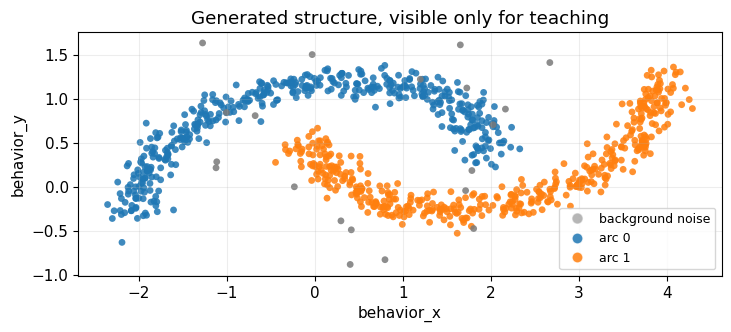

In [3]:
NOISE_COLOR = (0.48, 0.48, 0.48, 0.55)
CLUSTER_COLORS = [(*color, 0.86) for color in plt.cm.tab10.colors]


def colors_for_labels(labels):
    labels = np.asarray(labels)
    unique_clusters = sorted(label for label in np.unique(labels) if label != -1)
    color_lookup = {
        label: CLUSTER_COLORS[index % len(CLUSTER_COLORS)]
        for index, label in enumerate(unique_clusters)
    }
    color_lookup[-1] = NOISE_COLOR
    return [color_lookup[label] for label in labels], color_lookup


def plot_cluster_labels(ax, labels, title, label_names=None, centers=None):
    labels = np.asarray(labels)
    point_colors, color_lookup = colors_for_labels(labels)

    ax.scatter(
        data[FEATURES[0]],
        data[FEATURES[1]],
        c=point_colors,
        s=24,
        alpha=0.86,
        linewidths=0,
    )

    if centers is not None:
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="X",
            s=170,
            c="black",
            edgecolors="white",
            linewidths=1.3,
            label="centroid",
        )

    ax.set_title(title)
    ax.set_xlabel(FEATURES[0])
    ax.set_ylabel(FEATURES[1])
    ax.set_aspect("equal", adjustable="box")

    handles = []
    for label in sorted(np.unique(labels)):
        display_name = None
        if label_names is not None:
            display_name = label_names.get(int(label))
        if display_name is None:
            display_name = "noise" if label == -1 else f"cluster {label}"
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=color_lookup[label],
                markersize=8,
                label=display_name,
            )
        )
    if centers is not None:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="X",
                color="w",
                markerfacecolor="black",
                markeredgecolor="white",
                markersize=10,
                label="centroid",
            )
        )
    ax.legend(handles=handles, frameon=True, fontsize=9, loc="best")


true_label_names = {
    -1: "background noise",
    0: "arc 0",
    1: "arc 1",
}

fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)
plot_cluster_labels(ax, true_labels, "Generated structure, visible only for teaching", true_label_names)
plt.show()


## 2. Scale the Features

All three methods use distances. Scaling puts both coordinates on comparable units before a method computes centroids, density, or nearest neighbors.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[FEATURES])

scaled_summary = pd.DataFrame({
    "feature": FEATURES,
    "mean_after_scaling": X_scaled.mean(axis=0),
    "std_after_scaling": X_scaled.std(axis=0),
})

scaled_summary


,feature,mean_after_scaling,std_after_scaling
0,behavior_x,-1.3878e-17,1.0
1,behavior_y,-2.2482e-16,1.0


## 3. Fit the Three Clustering Methods

The methods get the same scaled feature matrix.

KMeans and Spectral Clustering are told that we want 2 clusters. HDBSCAN is not given a cluster count; it decides which dense regions are stable enough to keep and labels outliers as `-1`.

In [5]:
clusterers = {
    "KMeans (k=2)": KMeans(
        n_clusters=2,
        n_init=20,
        random_state=RANDOM_STATE,
    ),
    "HDBSCAN": HDBSCAN(
        min_cluster_size=35,
        min_samples=10,
    ),
    "Spectral Clustering (k=2)": SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    ),
}

cluster_results = {}
for method, estimator in clusterers.items():
    started = time.perf_counter()
    labels = estimator.fit_predict(X_scaled)
    elapsed = time.perf_counter() - started
    cluster_results[method] = {
        "estimator": estimator,
        "labels": labels,
        "fit_seconds": elapsed,
    }

pd.DataFrame({
    method: pd.Series(result["labels"]).value_counts().sort_index()
    for method, result in cluster_results.items()
}).fillna(0).astype(int)


,KMeans (k=2),HDBSCAN,Spectral Clustering (k=2)
-1,0,14,0
0,472,455,445
1,448,451,475


## 4. KMeans: Centroid-Based Partitions

KMeans repeatedly updates two things:

1. assign every point to the nearest centroid;
2. move each centroid to the mean of the points assigned to it.

That objective is fast and useful, but it creates convex regions. On curved clusters, the nearest-centroid rule cuts across the arcs instead of following them.

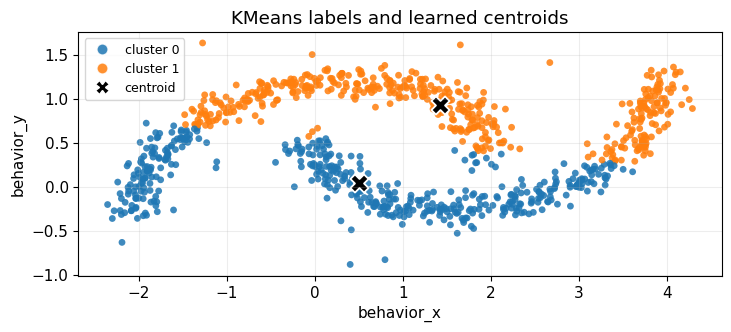

In [6]:
kmeans_result = cluster_results["KMeans (k=2)"]
kmeans_centers = scaler.inverse_transform(kmeans_result["estimator"].cluster_centers_)

fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)
plot_cluster_labels(
    ax,
    kmeans_result["labels"],
    "KMeans labels and learned centroids",
    centers=kmeans_centers,
)
plt.show()


## 5. HDBSCAN: Dense Regions and Noise

HDBSCAN is density based. It looks for regions where points stay connected across density levels and treats weakly connected points as noise.

This makes it useful when clusters are irregularly shaped or when some observations should not be forced into a cluster.

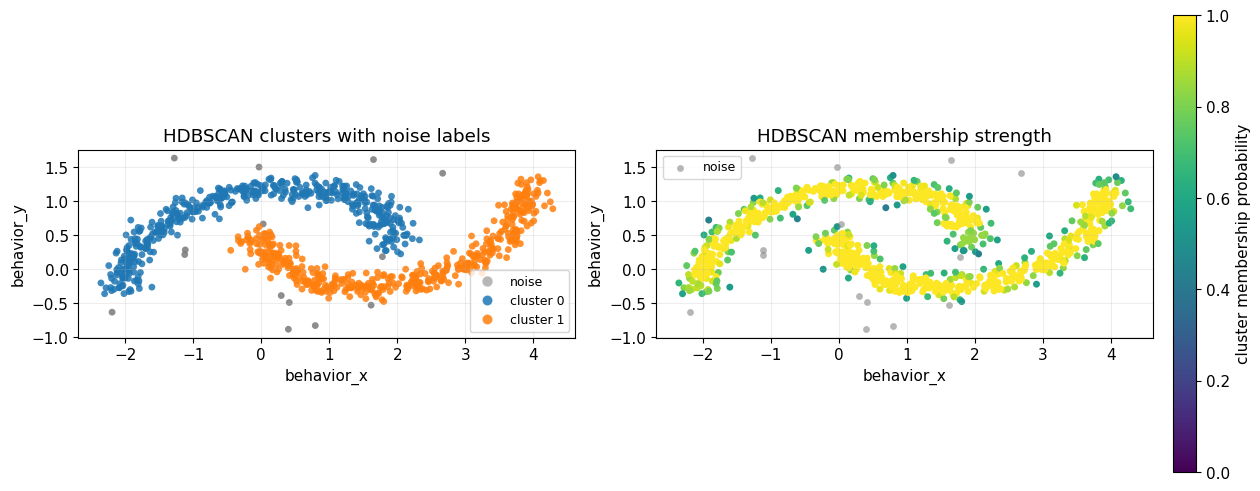

In [7]:
hdbscan_result = cluster_results["HDBSCAN"]
hdbscan_model = hdbscan_result["estimator"]
hdbscan_labels = hdbscan_result["labels"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
plot_cluster_labels(axes[0], hdbscan_labels, "HDBSCAN clusters with noise labels")

probabilities = np.asarray(hdbscan_model.probabilities_)
assigned_mask = hdbscan_labels != -1
axes[1].scatter(
    data.loc[assigned_mask, FEATURES[0]],
    data.loc[assigned_mask, FEATURES[1]],
    c=probabilities[assigned_mask],
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=25,
    linewidths=0,
)
axes[1].scatter(
    data.loc[~assigned_mask, FEATURES[0]],
    data.loc[~assigned_mask, FEATURES[1]],
    c=[NOISE_COLOR],
    s=24,
    linewidths=0,
    label="noise",
)
axes[1].set_title("HDBSCAN membership strength")
axes[1].set_xlabel(FEATURES[0])
axes[1].set_ylabel(FEATURES[1])
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend(frameon=True, fontsize=9, loc="best")
colorbar = fig.colorbar(axes[1].collections[0], ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("cluster membership probability")
plt.show()


## 6. Spectral Clustering: Cut a Neighbor Graph

Spectral Clustering first connects nearby points into a graph. It then uses the graph structure to find groups that are strongly connected internally and weakly connected to each other.

This is why it can separate curved shapes: nearby points along the same arc are connected even when the full arc is not compact around one centroid.

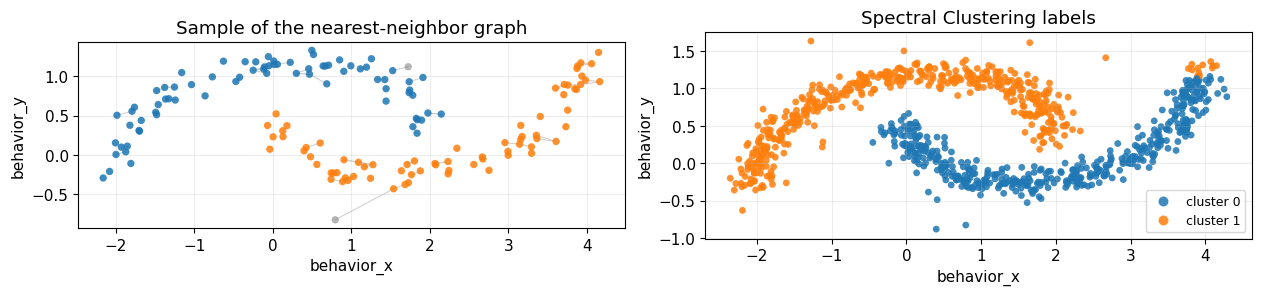

In [8]:
spectral_result = cluster_results["Spectral Clustering (k=2)"]

rng = np.random.default_rng(RANDOM_STATE)
sample_indices = rng.choice(np.arange(len(data)), size=150, replace=False)
sample_set = set(sample_indices.tolist())

neighbors = NearestNeighbors(n_neighbors=6)
neighbors.fit(X_scaled)
neighbor_indices = neighbors.kneighbors(return_distance=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)

for source_index in sample_indices:
    for target_index in neighbor_indices[source_index, 1:]:
        if target_index in sample_set:
            axes[0].plot(
                [data.iloc[source_index][FEATURES[0]], data.iloc[target_index][FEATURES[0]]],
                [data.iloc[source_index][FEATURES[1]], data.iloc[target_index][FEATURES[1]]],
                color="0.80",
                linewidth=0.7,
                zorder=1,
            )
axes[0].scatter(
    data.iloc[sample_indices][FEATURES[0]],
    data.iloc[sample_indices][FEATURES[1]],
    c=colors_for_labels(true_labels[sample_indices])[0],
    s=28,
    linewidths=0,
    zorder=2,
)
axes[0].set_title("Sample of the nearest-neighbor graph")
axes[0].set_xlabel(FEATURES[0])
axes[0].set_ylabel(FEATURES[1])
axes[0].set_aspect("equal", adjustable="box")

plot_cluster_labels(
    axes[1],
    spectral_result["labels"],
    "Spectral Clustering labels",
)
plt.show()


## 7. Compare Results

Because this is a teaching dataset, we can use the hidden generated labels to score the clusters.

`Adjusted Rand Index` compares predicted clusters with the generated groups. A value near 1 means high agreement. The score includes the background-noise label in the `ARI_all_rows` column, and excludes generated noise in `ARI_curves_only`.

`silhouette_assigned` is an internal compactness score. It ignores points predicted as noise. Notice that a method can have a reasonable silhouette score while still choosing the wrong curved split, so it should not be the only clustering criterion.

In [9]:
def count_clusters(labels):
    return len([label for label in np.unique(labels) if label != -1])


def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    assigned_mask = labels != -1
    assigned_labels = labels[assigned_mask]
    if assigned_mask.sum() < 3 or len(np.unique(assigned_labels)) < 2:
        return np.nan
    return silhouette_score(X[assigned_mask], assigned_labels)


clean_mask = true_labels != -1
comparison_rows = []

for method, result in cluster_results.items():
    labels = result["labels"]
    comparison_rows.append({
        "method": method,
        "needs_cluster_count": "no" if method == "HDBSCAN" else "yes",
        "clusters_found": count_clusters(labels),
        "predicted_noise_points": int((labels == -1).sum()),
        "ARI_all_rows": adjusted_rand_score(true_labels, labels),
        "ARI_curves_only": adjusted_rand_score(true_labels[clean_mask], labels[clean_mask]),
        "silhouette_assigned": safe_silhouette(X_scaled, labels),
        "fit_seconds": result["fit_seconds"],
    })

comparison = pd.DataFrame(comparison_rows)
for column in ["ARI_all_rows", "ARI_curves_only", "silhouette_assigned", "fit_seconds"]:
    comparison[column] = comparison[column].round(4)

comparison.sort_values("ARI_all_rows", ascending=False)


,method,needs_cluster_count,clusters_found,predicted_noise_points,ARI_all_rows,ARI_curves_only,silhouette_assigned,fit_seconds
1,HDBSCAN,no,2,14,0.9738,0.9933,0.3236,0.0158
2,Spectral Clustering (k=2),yes,2,0,0.9062,0.9473,0.3190,0.3699
0,KMeans (k=2),yes,2,0,0.1556,0.1626,0.3842,0.0915


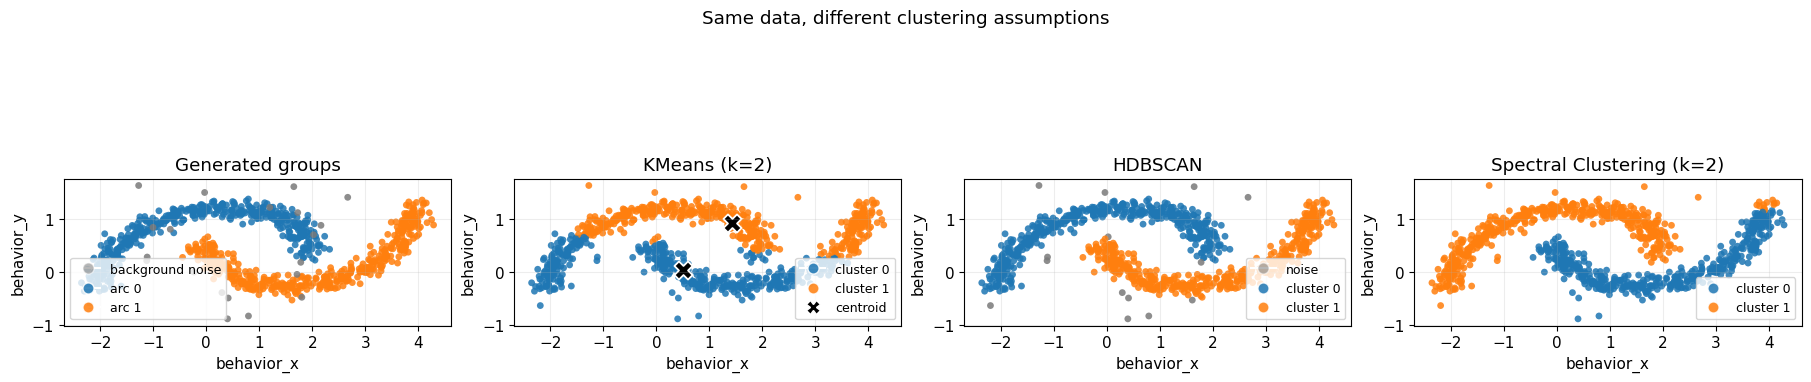

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
plot_cluster_labels(axes[0], true_labels, "Generated groups", true_label_names)

for ax, (method, result) in zip(axes[1:], cluster_results.items()):
    centers = None
    if method == "KMeans (k=2)":
        centers = scaler.inverse_transform(result["estimator"].cluster_centers_)
    plot_cluster_labels(ax, result["labels"], method, centers=centers)

fig.suptitle("Same data, different clustering assumptions", y=1.04)
plt.show()


## 8. Parameter Intuition

Clustering is unsupervised, but the algorithms still have assumptions.

The next cells vary the most important knobs:

- KMeans: the requested number of centroids, `k`;
- HDBSCAN: the minimum cluster size and local-density strictness;
- Spectral Clustering: the number of neighbors used to build the graph.

,k,inertia,ARI_all_rows,silhouette
0,2,1112.0395,0.1556,0.3842
1,3,669.3904,0.2507,0.4212
2,4,408.5706,0.2652,0.4541
3,5,338.3822,0.2728,0.4548
4,6,266.2209,0.2543,0.4537


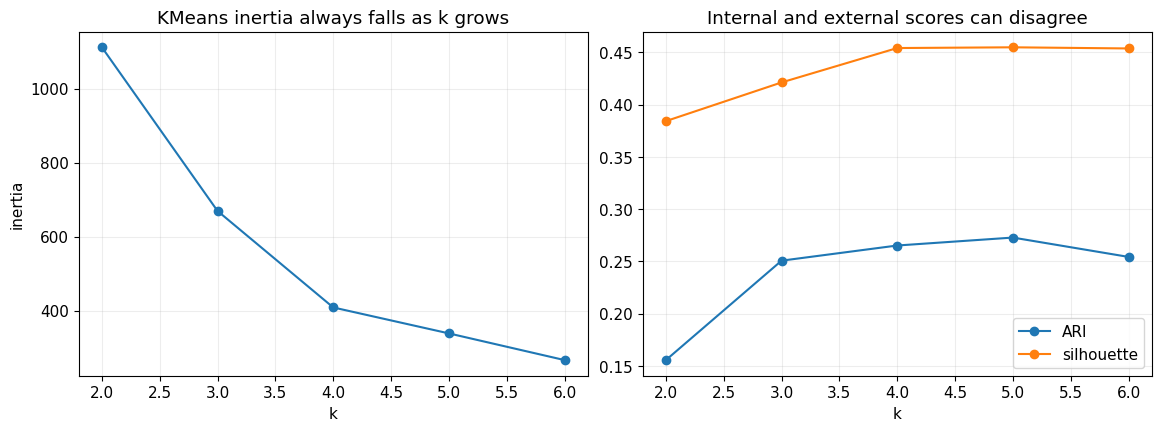

In [11]:
kmeans_rows = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    kmeans_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "ARI_all_rows": adjusted_rand_score(true_labels, labels),
        "silhouette": safe_silhouette(X_scaled, labels),
    })

kmeans_sweep = pd.DataFrame(kmeans_rows)
for column in ["inertia", "ARI_all_rows", "silhouette"]:
    kmeans_sweep[column] = kmeans_sweep[column].round(4)

display(kmeans_sweep)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
axes[0].plot(kmeans_sweep["k"], kmeans_sweep["inertia"], marker="o")
axes[0].set_title("KMeans inertia always falls as k grows")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")

axes[1].plot(kmeans_sweep["k"], kmeans_sweep["ARI_all_rows"], marker="o", label="ARI")
axes[1].plot(kmeans_sweep["k"], kmeans_sweep["silhouette"], marker="o", label="silhouette")
axes[1].set_title("Internal and external scores can disagree")
axes[1].set_xlabel("k")
axes[1].legend()
plt.show()


In [12]:
hdbscan_settings = [
    (15, 5),
    (25, 8),
    (35, 10),
    (55, 12),
    (90, 15),
]

hdbscan_rows = []
for min_cluster_size, min_samples in hdbscan_settings:
    model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
    )
    labels = model.fit_predict(X_scaled)
    hdbscan_rows.append({
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "clusters_found": count_clusters(labels),
        "predicted_noise_points": int((labels == -1).sum()),
        "ARI_all_rows": adjusted_rand_score(true_labels, labels),
        "ARI_curves_only": adjusted_rand_score(true_labels[clean_mask], labels[clean_mask]),
    })

hdbscan_sweep = pd.DataFrame(hdbscan_rows)
for column in ["ARI_all_rows", "ARI_curves_only"]:
    hdbscan_sweep[column] = hdbscan_sweep[column].round(4)

hdbscan_sweep


,min_cluster_size,min_samples,clusters_found,predicted_noise_points,ARI_all_rows,ARI_curves_only
0,15,5,2,10,0.9738,0.9978
1,25,8,2,12,0.9781,0.9978
2,35,10,2,14,0.9738,0.9933
3,55,12,2,15,0.9716,0.9911
4,90,15,2,17,0.9631,0.9845


,n_neighbors,ARI_all_rows,ARI_curves_only,silhouette
0,4,0.7023,0.7355,0.3159
1,6,0.8247,0.8627,0.3165
2,8,0.8488,0.8877,0.3171
3,10,0.9062,0.9473,0.3190
4,14,0.8338,0.8710,0.3496
5,20,0.8377,0.8751,0.3490
6,35,0.7077,0.7393,0.3620
7,60,0.7077,0.7393,0.3620


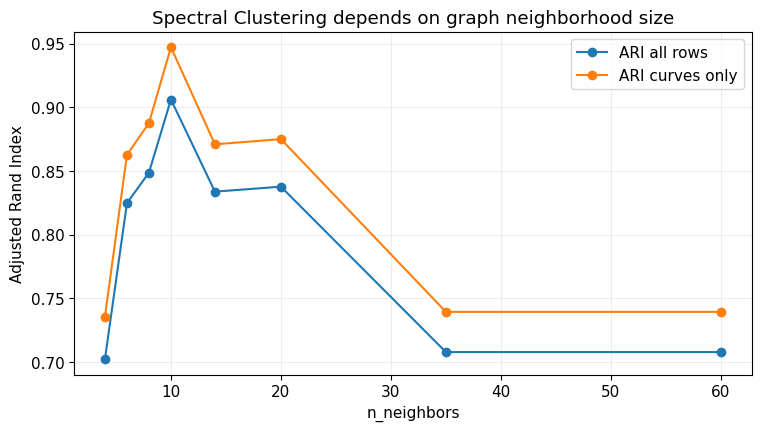

In [13]:
neighbor_settings = [4, 6, 8, 10, 14, 20, 35, 60]

spectral_rows = []
for n_neighbors in neighbor_settings:
    model = SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_scaled)
    spectral_rows.append({
        "n_neighbors": n_neighbors,
        "ARI_all_rows": adjusted_rand_score(true_labels, labels),
        "ARI_curves_only": adjusted_rand_score(true_labels[clean_mask], labels[clean_mask]),
        "silhouette": safe_silhouette(X_scaled, labels),
    })

spectral_sweep = pd.DataFrame(spectral_rows)
for column in ["ARI_all_rows", "ARI_curves_only", "silhouette"]:
    spectral_sweep[column] = spectral_sweep[column].round(4)

display(spectral_sweep)

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(spectral_sweep["n_neighbors"], spectral_sweep["ARI_all_rows"], marker="o", label="ARI all rows")
ax.plot(spectral_sweep["n_neighbors"], spectral_sweep["ARI_curves_only"], marker="o", label="ARI curves only")
ax.set_title("Spectral Clustering depends on graph neighborhood size")
ax.set_xlabel("n_neighbors")
ax.set_ylabel("Adjusted Rand Index")
ax.legend()
plt.show()


## 9. Practical Takeaways

Use **KMeans** when clusters are expected to be compact, similarly sized, and roughly convex. It is fast and has useful centroids, but it forces every point into a cluster and struggles with curved shapes.

Use **HDBSCAN** when the data may contain noise, outliers, irregular shapes, or an unknown number of clusters. Its labels are often more conservative because uncertain points can become noise.

Use **Spectral Clustering** when graph connectivity matters more than centroid distance, especially for non-convex shapes. It can work very well on curved groups, but it needs a cluster count and a sensible neighbor graph.